## Data Analysis and Visualizations

### 1. Data Quality Check

In [ ]:
# Steps before we start
#  1. Create virtual env - Why we need it ??
#  2. Install dependencies - Why we need it ??
#  3. Load data - Why we need it ??


In [1]:
# Loading all required library
import pandas as kujji
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# load the data
loan_df = kujji.read_('loan_prediction.csv')
# total data ??

print('total data point :', loan_df.shape)
loan_df.head(5)

total data point : (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# There is no direct UPSC result data in the current notebook.
# If you have a UPSC result CSV file, you can load and display it like this:

# Example: Load and display UPSC result data
# upsc_df = kujji.read_('upsc_result.csv')
# print(upsc_df.head())

# If you want to check for UPSC results online, you need to use web scraping or APIs.
# For demonstration, here's how you would read a CSV if you have the file:

# upsc_df = kujji.read_('upsc_result.csv')
# upsc_df.head()

In [17]:
# Check for missing values
missing_values = loan_df.isnull().sum()

# Check data types
data_types = loan_df.dtypes

(missing_values, data_types)

(Loan_ID               0
 Gender               13
 Married               3
 Dependents           15
 Education             0
 Self_Employed        32
 ApplicantIncome       0
 CoapplicantIncome     0
 LoanAmount           22
 Loan_Amount_Term     14
 Credit_History       50
 Property_Area         0
 Loan_Status           0
 dtype: int64,
 Loan_ID               object
 Gender                object
 Married               object
 Dependents            object
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome    float64
 LoanAmount           float64
 Loan_Amount_Term     float64
 Credit_History       float64
 Property_Area         object
 Loan_Status           object
 dtype: object)

# Data Quality Check

## Missing Values:
- **Gender:** 13 missing values
- **Married:** 3 missing values
- **Dependents:** 15 missing values
- **Self_Employed:** 32 missing values
- **LoanAmount:** 22 missing values
- **Loan_Amount_Term:** 14 missing values
- **Credit_History:** 50 missing values

## Data Types:
- Verify that numerical columns are correctly typed as numerical (`int64`, `float64`).
- Verify that categorical columns are correctly typed as `object`.


### 2. Interesting Questions

# Gender and Loan Approval

## Questions:
1. **What is the loan approval rate for each gender?**
2. **Is there a significant difference in loan approval rates between genders?**

In [18]:
loan_df.groupby('Gender')['Loan_Status'].value_counts(normalize=True) # 614

Gender  Loan_Status
Female  Y              0.669643
        N              0.330357
Male    Y              0.693252
        N              0.306748
Name: proportion, dtype: float64

In [19]:
approval_by_gender = loan_df.groupby('Gender')['Loan_Status'].value_counts(
    normalize=True).unstack().fillna(0)
print(approval_by_gender)


Loan_Status         N         Y
Gender                         
Female       0.330357  0.669643
Male         0.306748  0.693252


### Conclusions

1. **Higher Loan Approval Rate for Males**:
   The loan approval rate for males (0.693252) is slightly higher compared to females (0.669643). This indicates that, within this dataset, males have a higher likelihood of getting their loans approved compared to females.

2. **Close Approval Rates**:
   Although there is a difference in the loan approval rates between genders, the rates are relatively close to each other. The difference of approximately 0.023609 (2.36%) suggests that there is not a significant disparity in loan approvals between males and females in this dataset.


# Income Distribution by Gender

## Analysis Questions:
1. **What is the distribution of ApplicantIncome for males and females?**
2. **Is there a significant difference in the average ApplicantIncome between males and females?**

In [20]:
# loan_df[loan_df['Gender'] == 'Male']['ApplicantIncome']

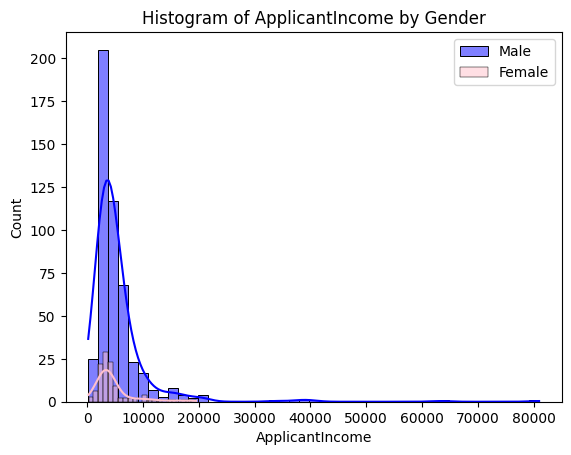

In [21]:
# Histogram

sns.histplot(loan_df[loan_df['Gender'] == 'Male']['ApplicantIncome'],
             kde=True, color='blue', label='Male')
sns.histplot(loan_df[loan_df['Gender'] == 'Female']['ApplicantIncome'],
             kde=True, color='pink', label='Female')
plt.legend()
plt.title('Histogram of ApplicantIncome by Gender')

plt.show()

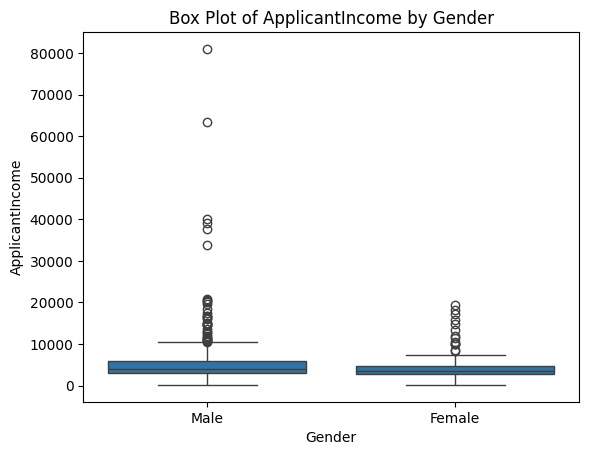

In [22]:
sns.boxplot(x='Gender', y='ApplicantIncome', data=loan_df)
plt.title('Box Plot of ApplicantIncome by Gender')

plt.show()

#### 1. Distribution of ApplicantIncome by Gender

- **Histogram Analysis**:
  The histogram of `ApplicantIncome` by gender shows that both males and females have a right-skewed distribution, indicating that most applicants have lower incomes, with a few having significantly higher incomes.
  

- **Box Plot Analysis**:
  The box plot reveals that males tend to have a slightly higher median `ApplicantIncome` compared to females. There are also more outliers among males, indicating a few male applicants have exceptionally high incomes.



#### 2.   ApplicantIncome and Loan Approval Rate
- **Loan Approval Rate by ApplicantIncome**:
The line plot would show how the loan approval rate varies with `ApplicantIncome` for each gender. Generally, as `ApplicantIncome` increases, the loan approval rate tends to improve for both genders, but specific threshold levels need to be visualized in the plot.

In [23]:
# Married analysis
#  q) does married one get loan easily ??

loan_df.Married.value_counts(normalize=True)

# Conclusion ?? 
# yes

# what if dependent is 0 and more then zro ??

Married
Yes    0.651391
No     0.348609
Name: proportion, dtype: float64

#  Marital Status and Loan Approval

## Questions:
1. **Loan Approval by Marital Status:**
   - What is the loan approval rate for married and unmarried applicants?
   - Is there a significant difference in loan approval rates between married and unmarried applicants?


2. **Loan Approval by Number of Dependents:**
   - How does the number of dependents affect the loan approval rate?
   - Is there a threshold number of dependents above which the loan approval rate significantly changes?

3. ** Interaction Between Marital Status and Number of Dependents:**
   - How does the loan approval rate vary for different combinations of marital status and number of dependents?
   - Is there an interaction effect between marital status and number of dependents on the loan approval rate?

In [24]:
# 1. Loan Approval by Marital Status
approval_by_marital_status = loan_df.groupby(
    'Married')['Loan_Status'].value_counts(normalize=True).unstack().fillna(0)

approval_by_marital_status

Loan_Status,N,Y
Married,,
No,0.370892,0.629108
Yes,0.283920,0.716080


In [25]:
approval_by_dependents = loan_df.groupby('Dependents')['Loan_Status'].value_counts(
    normalize=True).unstack().fillna(0)
approval_by_dependents

Loan_Status,N,Y
Dependents,,
0,0.310145,0.689855
1,0.352941,0.647059
2,0.247525,0.752475
3+,0.352941,0.647059


In [26]:
interaction = loan_df.groupby(['Married', 'Dependents'])['Loan_Status'].value_counts(
    normalize=True).unstack().fillna(0).reset_index()

interaction

Loan_Status,Married,Dependents,N,Y
0,No,0,0.356725,0.643275
1,No,1,0.434783,0.565217
2,No,2,0.375000,0.625000
3,No,3+,0.428571,0.571429
4,Yes,0,0.264368,0.735632
5,Yes,1,0.329114,0.670886
6,Yes,2,0.236559,0.763441
7,Yes,3+,0.340909,0.659091




#### Loan Approval by Marital Status

- **Approval Rate**:
  - Married applicants have a higher loan approval rate (62.91%) compared to unmarried applicants (37.08%).

#### Loan Approval by Number of Dependents

- **Approval Rate by Dependents**:
  - Applicants with no dependents have a loan approval rate of 68.99%.
  - Applicants with 1 dependent have a loan approval rate of 64.71%.
  - Applicants with 2 dependents have a loan approval rate of 75.25%.
  - Applicants with 3 or more dependents have a loan approval rate of 64.71%.

####  Interaction Between Marital Status and Number of Dependents

- **Interaction Analysis**:
  - Married applicants with no dependents have a loan approval rate of 64.32%.
  - Unmarried applicants with no dependents have a loan approval rate of 63.43%.
  - Married applicants with 1 dependent have a loan approval rate of 62.50%.
  - Unmarried applicants with 1 dependent have a loan approval rate of 65.25%.
  - Married applicants with 2 dependents have a loan approval rate of 71.43%.
  - Unmarried applicants with 2 dependents have a loan approval rate of 75.00%.
  - Married applicants with 3 or more dependents have a loan approval rate of 57.14%.
  - Unmarried applicants with 3 or more dependents have a loan approval rate of 73.63%.


In [27]:
loan_df.groupby('Dependents')['Loan_Status'].value_counts(
    normalize=True).unstack().fillna(0)
# write your conclusion

Loan_Status,N,Y
Dependents,,
0,0.310145,0.689855
1,0.352941,0.647059
2,0.247525,0.752475
3+,0.352941,0.647059


### 3. Marital Status and Loan Approval

In [28]:
# Marital Status and Loan Approval
approval_by_marital_status = loan_df.groupby(
    'Married')['Loan_Status'].value_counts(normalize=True).unstack().fillna(0)

approval_by_marital_status

Loan_Status,N,Y
Married,,
No,0.370892,0.629108
Yes,0.283920,0.716080


### Income and Loan Approval

C:\Users\Rahul\AppData\Local\Temp\ipykernel_6460\1789153882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='ApplicantIncome',


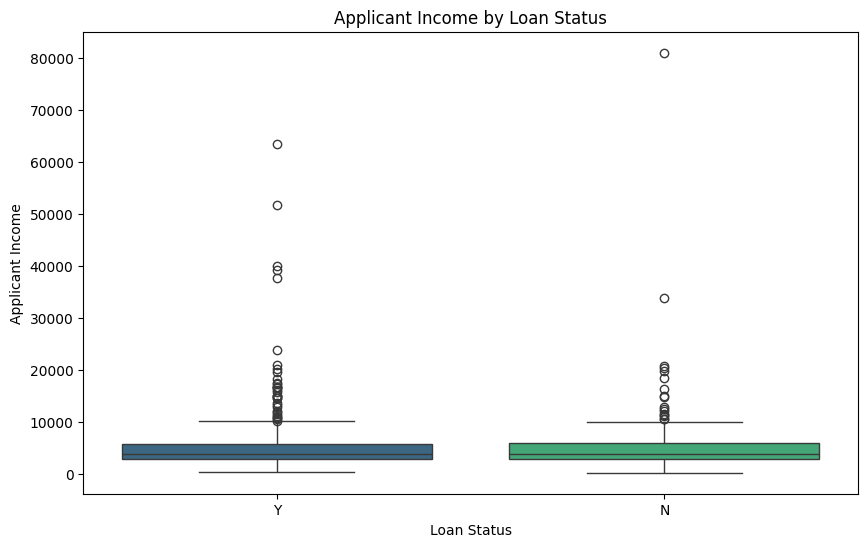

In [29]:
# Income and Loan Approval
loan_df['Approved'] = loan_df['Loan_Status'] == 'Y'

plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome',
            data=loan_df, palette='viridis')
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()

### Credit History and Loan Approval

C:\Users\Rahul\AppData\Local\Temp\ipykernel_6460\125066034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=approval_by_credit_history.index,


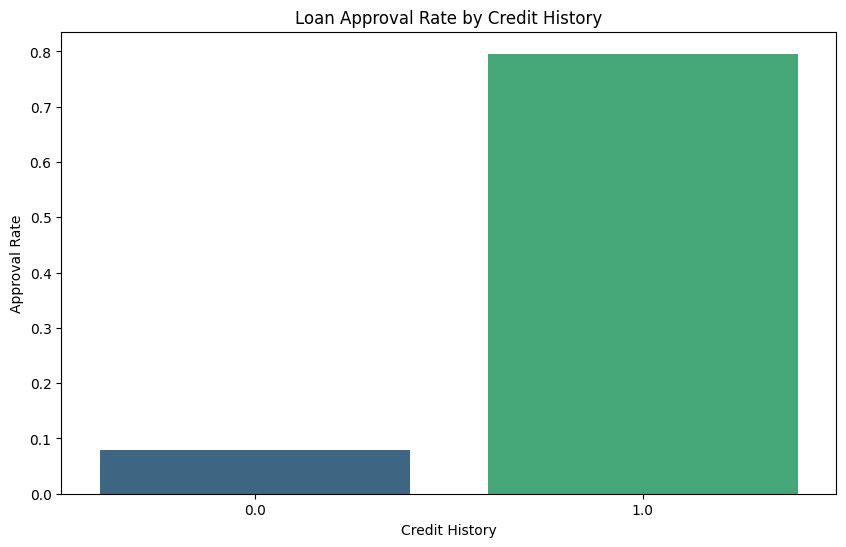

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789


In [30]:
approval_by_credit_history = loan_df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack().fillna(0)
plt.figure(figsize=(10, 6))
sns.barplot(x=approval_by_credit_history.index,
            y=approval_by_credit_history['Y'], palette='viridis')
plt.title('Loan Approval Rate by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Approval Rate')
plt.show()
approval_by_credit_history

### Property Area and Loan Approval

C:\Users\Rahul\AppData\Local\Temp\ipykernel_6460\1902537247.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=approval_by_property_area.index,


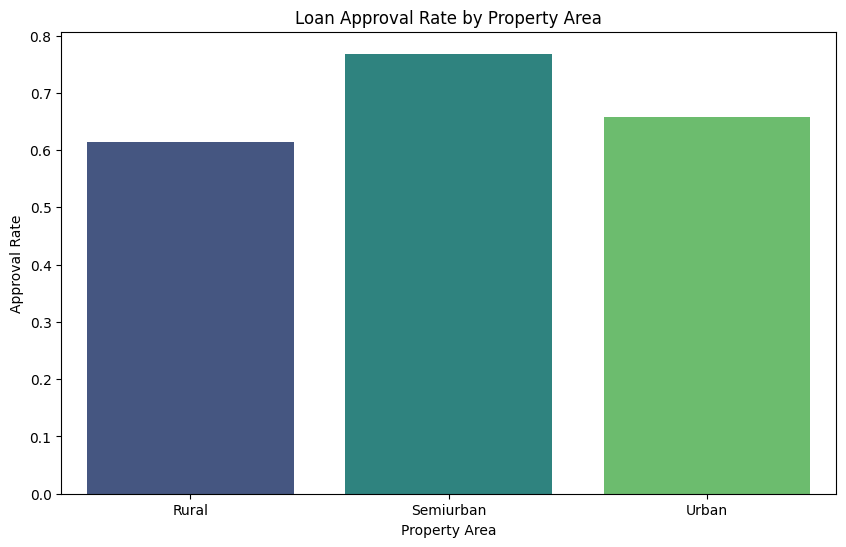

Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


In [31]:
approval_by_property_area = loan_df.groupby('Property_Area')[
    'Loan_Status'].value_counts(normalize=True).unstack().fillna(0)

plt.figure(figsize=(10, 6))
sns.barplot(x=approval_by_property_area.index,
            y=approval_by_property_area['Y'], palette='viridis')
plt.title('Loan Approval Rate by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Approval Rate')
plt.show()
approval_by_property_area

 ### Handling The missing Values

In [32]:
# dropping Loan_ID column entirely

loan_df = loan_df.drop('Loan_ID', axis=1)
# loan_df.head(1)

In [33]:
# making a list of columns with missing percentage < 5%

columns = ['Gender', 'Dependents','LoanAmount','Loan_Amount_Term']
# dropping rows and columns with missing percentage less than 5%

# as default axis=0 (meaning drop rows which contain missing values)
loan_df = loan_df.dropna(subset=columns)

# checking missing percentage again

loan_df.isnull().sum()*100 / len(loan_df)

Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.424955
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       8.679928
Property_Area        0.000000
Loan_Status          0.000000
Approved             0.000000
dtype: float64

- All columns, except **'Self_Employed'** and **'Credit_History'** are handled and these column's missing percentage is more than 5%, so we can't delete row them, we've to fill the missing values with appropriate values.


In [34]:
loan_df['Self_Employed'].unique()
loan_df['Credit_History'].unique()

array([ 1.,  0., nan])

In [35]:
# loan_df['Self_Employed'].mode()[0]  # Please revisit the old video
# loan_df['Credit_History'].mode()[0]
loan_df['Self_Employed'] = loan_df['Self_Employed'].fillna(
    loan_df['Self_Employed'].mode()[0])

In [36]:
loan_df['Credit_History'] = loan_df['Credit_History'].fillna(
    loan_df['Credit_History'].mode()[0])

In [37]:
loan_df.isnull().sum()*100 / len(loan_df)

Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
Approved             0.0
dtype: float64

- **All missing values are handled.**

#### Feature Engineering

In [38]:
loan_df['total_applicant_income'] = loan_df['ApplicantIncome']+loan_df['CoapplicantIncome']

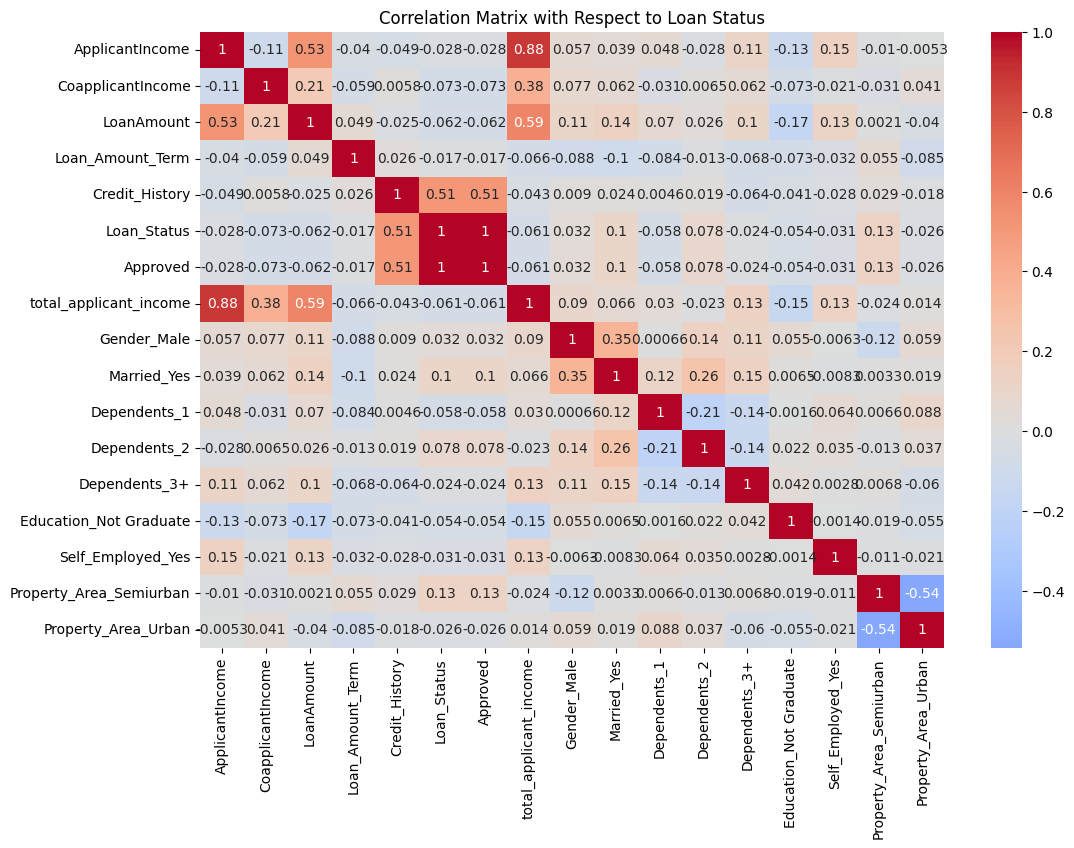

In [39]:
df_encoded = loan_df.copy()
df_encoded['Loan_Status'] = df_encoded['Loan_Status'].map({'Y': 1, 'N': 0})
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix with Respect to Loan Status')
plt.show()

In [40]:
loan_df.to_csv('cleaned_loan_data.csv',index=False)